# Graficos OCDE desde el crawler

Este notebook usa los CSV generados por `crawler/descargar_ocde_ia.py`
en `Data/ocde_ia/` y guarda los resultados en `graficos_api_ocde/`.


In [17]:
import importlib
import graficos_crawler

importlib.reload(graficos_crawler)

resumen = graficos_crawler.generar_graficos_ocde()
resumen.head(15)

[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\ocde_grafico_01_empresas_ia.png
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\data\ocde_grafico_01_empresas_ia_datos.csv
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\ocde_grafico_02_gasto_id.png
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\data\ocde_grafico_02_gasto_id_datos.csv
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\ocde_grafico_03_publicaciones_ia.png
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\data\ocde_grafico_03_publicaciones_ia_datos.csv
[WARN] No hay datos para ocde_grafico_04_patentes_ia.png
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\ocde_grafico_05_inversion_ia.png
[OK] Guardado: C:\Users\marti\Desktop\Computacion-cientifica\graficos_api_ocde\data\ocde_grafico_05_inversion_ia_datos.csv
[OK] 

,chart,rank,pais,valor_agregado
0,grafico_01_empresas_ia,1,Korea,35.0
1,grafico_01_empresas_ia,2,Germany,14.0
2,grafico_01_empresas_ia,3,Denmark,12.0
3,grafico_01_empresas_ia,4,Italy,6.0
4,grafico_01_empresas_ia,5,United Kingdom,5.0
5,grafico_01_empresas_ia,6,Latvia,5.0
6,grafico_01_empresas_ia,7,Canada,4.0
7,grafico_01_empresas_ia,8,Estonia,4.0
8,grafico_01_empresas_ia,9,Chile,4.0
9,grafico_01_empresas_ia,10,Netherlands,4.0


In [18]:
from pathlib import Path

sorted(path.name for path in Path('graficos_api_ocde').glob('ocde_grafico_*.png'))


['ocde_grafico_01_empresas_ia.png',
 'ocde_grafico_02_gasto_id.png',
 'ocde_grafico_03_publicaciones_ia.png',
 'ocde_grafico_04_patentes_ia.png',
 'ocde_grafico_05_inversion_ia.png',
 'ocde_grafico_06_rd_vs_ia.png']

---
## Mapa revisado: patentes de IA por pais (OCDE, 2022-2025)

Objetivo: rehacer el mapa con una escala entendible y con mas cobertura de paises.

Cambios respecto al mapa anterior:
- se consulta directamente la API SDMX de la OCDE para 2022-2025;
- ya no se suman oficinas de patentes, roles y tipos de fecha distintos;
- se usa un corte consistente: `WIPO + Patent applications + Priority date + Inventor`;
- la escala ya no es logaritmica: el color se suaviza para legibilidad, pero la barra muestra valores reales;
- si 2025 no aparece, el notebook lo reporta explicitamente.



In [19]:
import io
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("Data/ocde_ia")
DATA_DIR.mkdir(parents=True, exist_ok=True)

API_URL = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.STI.PIE,DSD_PATENTS@DF_PATENTS_OECDSPECIFIC,1.0/all"
)
params = {
    "startPeriod": "2022",
    "endPeriod": "2025",
    "dimensionAtObservation": "AllDimensions",
    "format": "csvfilewithlabels",
}
headers = {"User-Agent": "Mozilla/5.0 OECD-AI-patents-notebook/1.0"}

response = requests.get(API_URL, params=params, headers=headers, timeout=90)
response.raise_for_status()

raw_pat = pd.read_csv(io.StringIO(response.text), low_memory=False)
raw_pat["OBS_VALUE"] = pd.to_numeric(raw_pat["OBS_VALUE"], errors="coerce")
raw_pat["TIME_PERIOD"] = pd.to_numeric(raw_pat["TIME_PERIOD"], errors="coerce").astype("Int64")

blocked_pattern = r"world|oecd|european union|euro area|non-oecd|not applicable"
mask = (
    raw_pat["Selected OECD technology domains"].astype(str).str.strip().str.lower().eq(
        "technologies related to artificial intelligence"
    )
    & raw_pat["Measure"].astype(str).eq("Patent applications")
    & raw_pat["Patent authorities"].astype(str).eq("World Intellectual Property Organization")
    & raw_pat["Reference date type"].astype(str).eq("Priority date")
    & raw_pat["Agent role"].astype(str).eq("Inventor")
    & raw_pat["OBS_VALUE"].notna()
    & (raw_pat["OBS_VALUE"] > 0)
    & ~raw_pat["Reference area"].fillna("").str.lower().str.contains(blocked_pattern, regex=True)
)

ai_patents = (
    raw_pat.loc[
        mask,
        [
            "REF_AREA",
            "Reference area",
            "TIME_PERIOD",
            "OBS_VALUE",
            "Patent authorities",
            "Reference date type",
            "Agent role",
        ],
    ]
    .rename(
        columns={
            "Reference area": "country",
            "TIME_PERIOD": "year",
            "OBS_VALUE": "ai_patent_applications",
        }
    )
    .sort_values(["year", "ai_patent_applications"], ascending=[True, False])
    .reset_index(drop=True)
)

csv_path = DATA_DIR / "oecd_ai_patents_2022_2025_wipo_priority_inventor.csv"
ai_patents.to_csv(csv_path, index=False, encoding="utf-8-sig")

availability = (
    ai_patents.groupby("year", as_index=False)
    .agg(
        countries=("REF_AREA", "nunique"),
        ai_patent_applications=("ai_patent_applications", "sum"),
    )
)

if 2025 not in availability["year"].tolist():
    print(
        "La API de la OCDE no devolvio observaciones para 2025 en esta serie "
        "(consulta realizada el 2026-05-01, hora de Santiago)."
    )

print(f"CSV filtrado guardado en: {csv_path}")
availability



La API de la OCDE no devolvio observaciones para 2025 en esta serie (consulta realizada el 2026-05-01, hora de Santiago).
CSV filtrado guardado en: Data\ocde_ia\oecd_ai_patents_2022_2025_wipo_priority_inventor.csv


,year,countries,ai_patent_applications
0,2022,69,15804.999693
1,2023,84,16724.754079
2,2024,84,17866.041062


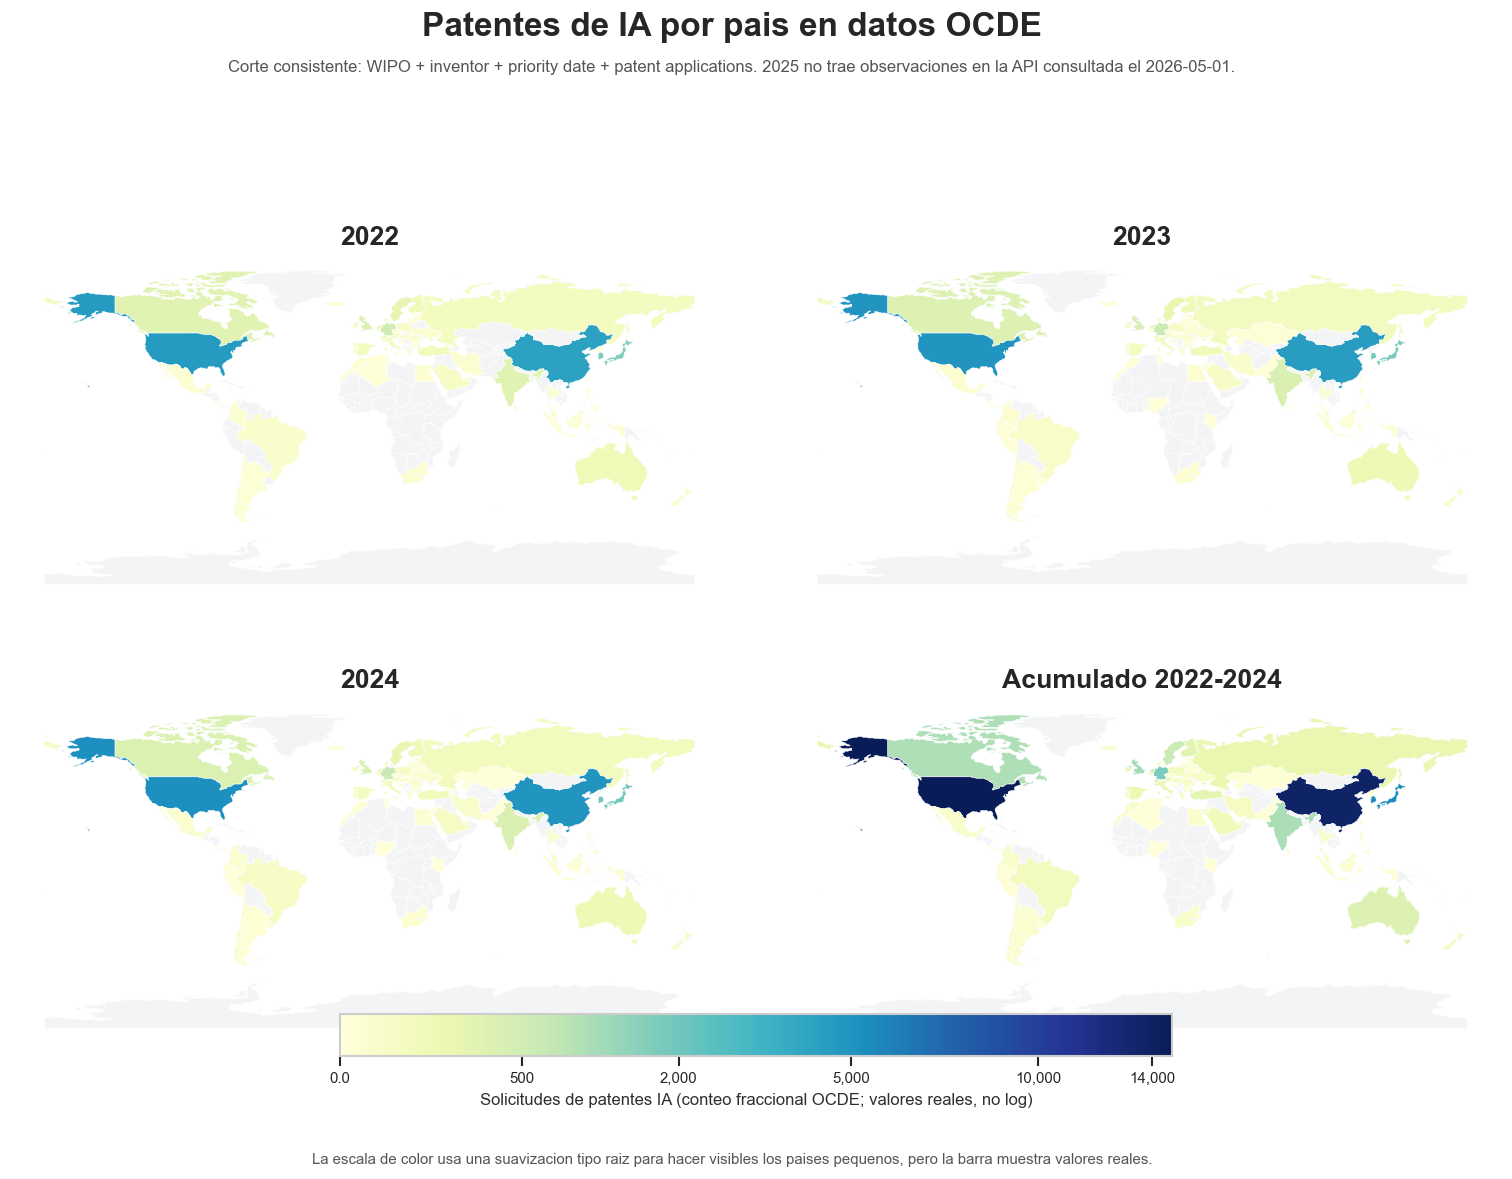

Mapa guardado en: Data\ocde_ia\mapa_patentes_ia_ocde_2022_2024.png


In [20]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import PowerNorm
from matplotlib.ticker import FuncFormatter

map_path = DATA_DIR / "mapa_patentes_ia_ocde_2022_2024.png"

try:
    import geopandas as gpd
except ModuleNotFoundError:
    if not map_path.exists():
        raise ModuleNotFoundError(
            "Falta geopandas para regenerar el mapa y tampoco existe el PNG de respaldo. "
            "Instala geopandas o genera antes el archivo en Data/ocde_ia/."
        )

    img = mpimg.imread(map_path)
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.imshow(img)
    ax.axis("off")
    plt.show()
    print(
        "Se mostro el PNG ya generado porque este kernel no tiene geopandas: "
        f"{map_path}"
    )
else:
    world = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    )
    world.columns = [col.lower() for col in world.columns]
    iso_candidates = ["iso_a3", "adm0_a3", "sov_a3", "adm0_a3_us"]
    iso_col = next((col for col in iso_candidates if col in world.columns), None)
    if iso_col is None:
        raise KeyError("No se encontro columna ISO en el shapefile")

    world = world[world[iso_col] != "-99"].copy().rename(columns={iso_col: "iso_a3"})

    year_country = (
        ai_patents.groupby(["year", "REF_AREA", "country"], as_index=False)["ai_patent_applications"]
        .sum()
    )
    cum_country = (
        year_country.groupby(["REF_AREA", "country"], as_index=False)["ai_patent_applications"]
        .sum()
    )

    years_to_plot = [2022, 2023, 2024]
    vmax = max(
        year_country["ai_patent_applications"].max(),
        cum_country["ai_patent_applications"].max(),
    )
    norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    for ax, year in zip(axes[:3], years_to_plot):
        merged = world.merge(
            year_country[year_country["year"] == year],
            left_on="iso_a3",
            right_on="REF_AREA",
            how="left",
        )
        world.plot(ax=ax, color="#f3f4f6", edgecolor="white", linewidth=0.35)
        merged.plot(
            column="ai_patent_applications",
            ax=ax,
            cmap="YlGnBu",
            norm=norm,
            edgecolor="white",
            linewidth=0.35,
            missing_kwds={"color": "#f3f4f6"},
        )
        ax.set_title(str(year), fontsize=16)
        ax.axis("off")

    ax = axes[3]
    merged = world.merge(cum_country, left_on="iso_a3", right_on="REF_AREA", how="left")
    world.plot(ax=ax, color="#f3f4f6", edgecolor="white", linewidth=0.35)
    merged.plot(
        column="ai_patent_applications",
        ax=ax,
        cmap="YlGnBu",
        norm=norm,
        edgecolor="white",
        linewidth=0.35,
        missing_kwds={"color": "#f3f4f6"},
    )
    ax.set_title("Acumulado 2022-2024", fontsize=16)
    ax.axis("off")

    sm = ScalarMappable(norm=norm, cmap="YlGnBu")
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.045, pad=0.04)
    cbar.set_label("Solicitudes de patentes IA (conteo fraccional OCDE; valores reales, no log)")
    cbar.set_ticks([0, 500, 2000, 5000, 10000, 14000])
    cbar.ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:,.0f}" if x >= 10 else f"{x:.1f}")
    )

    fig.suptitle("Patentes de IA por pais en datos OCDE", fontsize=20, fontweight="bold", y=0.98)
    fig.text(
        0.5,
        0.93,
        "Corte consistente: WIPO + inventor + priority date + patent applications. 2025 no trae observaciones en la API consultada el 2026-05-01.",
        ha="center",
        fontsize=10,
        color="#555555",
    )
    fig.text(
        0.5,
        0.02,
        "La escala de color usa una suavizacion tipo raiz para hacer visibles los paises pequenos, pero la barra muestra valores reales.",
        ha="center",
        fontsize=9,
        color="#555555",
    )
    fig.subplots_adjust(top=0.82, bottom=0.12, wspace=0.08, hspace=0.12)

    fig.savefig(map_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Mapa guardado en: {map_path}")



Interpretacion:
- este mapa usa solicitudes de patentes IA de WIPO, con pais del inventor y fecha de prioridad, para evitar duplicaciones entre USPTO, EPO y WIPO;
- 2025 no trae observaciones en la API de la OCDE consultada el 2026-05-01, por eso el acumulado comparable queda en 2022-2024;
- los valores son conteos fraccionales, por eso pueden aparecer decimales;
- paises en gris no tienen observaciones positivas en este corte.



---
## Análisis Adicional de Patentes de IA (OCDE)

A partir de los datos recolectados, generaremos dos gráficos adicionales para visualizar:
1. **Evolución temporal (2022-2024)** de los 8 países con más patentes en IA.
2. **Top 15 países** con mayor cantidad de patentes en el último año disponible (2024).


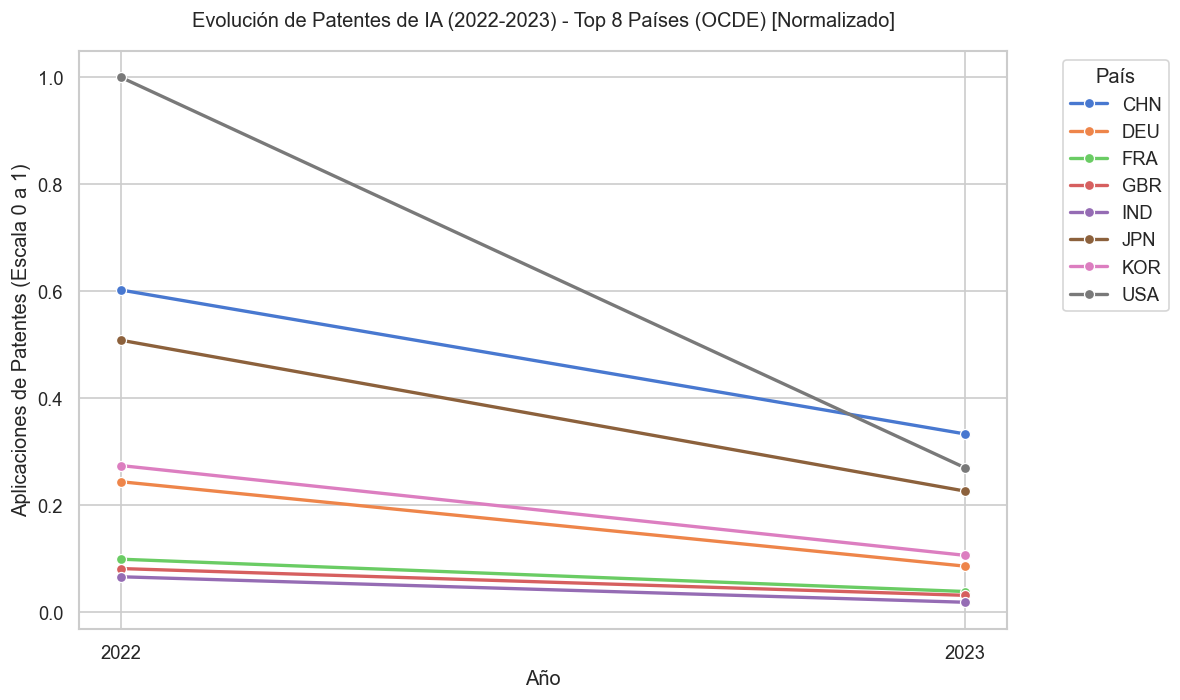

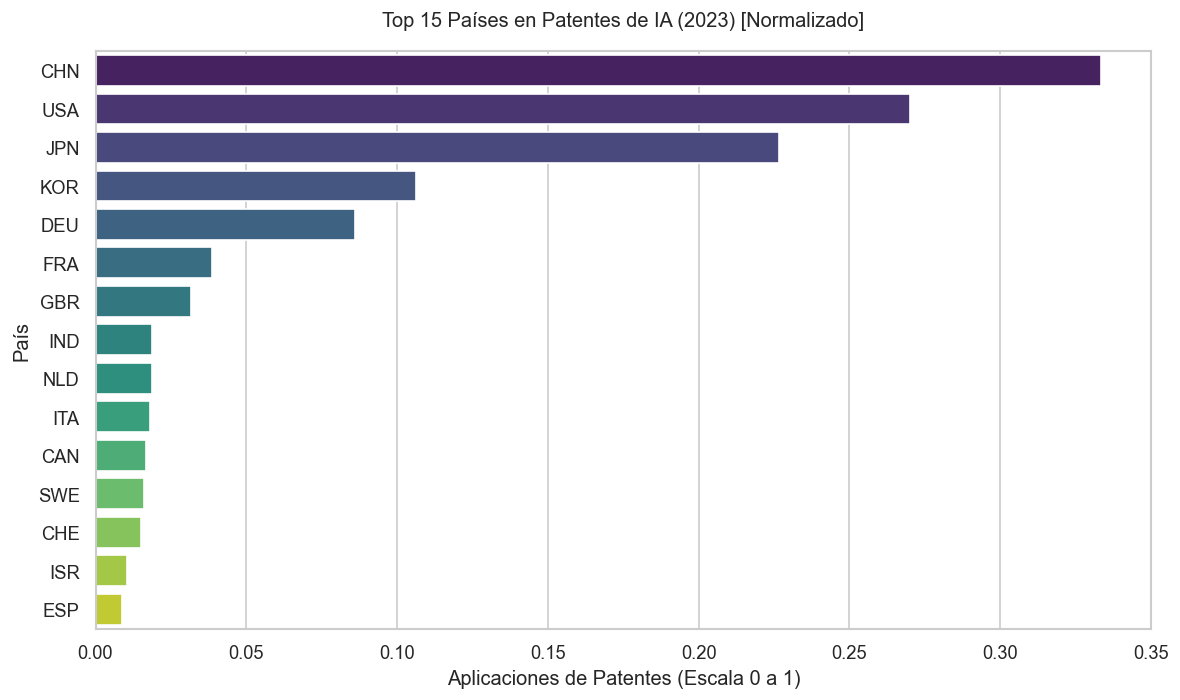

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# 1. Leer el dataset
df_raw = pd.read_csv('OECD.STI.PIE,DSD_PATENTS@DF_PATENTS_OECDSPECIFIC,1.0+.A...PRIORITY...INVENTOR..._T.csv')

# 2. Filtrar y limpiar
# Usamos Measure == 'AP' para evitar duplicar con Familias (PF)
df = df_raw[df_raw['MEASURE'] == 'AP'].copy()

# Renombrar columnas para compatibilidad
df = df.rename(columns={
    'REF_AREA': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'ai_patent_applications'
})

# Filtrar agregados (World, OECD, EU)
df = df[~df['country'].isin(['W', 'OECD', 'EU27_2020'])]

# 3. Consolidar por país y año
df = df.groupby(['country', 'year'], as_index=False)['ai_patent_applications'].sum()

# ---------------------------------------------------------
# 4. NORMALIZACIÓN DE LOS DATOS (Min-Max Scaling)
# ---------------------------------------------------------
# Se crea una nueva columna para mantener intactos los datos crudos si los necesitas después.
min_val = df['ai_patent_applications'].min()
max_val = df['ai_patent_applications'].max()

df['ai_patent_applications_norm'] = (df['ai_patent_applications'] - min_val) / (max_val - min_val)


# 5. Gráfico 1: Evolución Temporal Top 8
# Identificamos el Top 8 usando los datos originales para mantener la precisión del ranking
top_countries = df.groupby('country')['ai_patent_applications'].sum().nlargest(8).index
df_top = df[df['country'].isin(top_countries)]

plt.figure(figsize=(10, 6))
# Usamos la columna normalizada 'ai_patent_applications_norm' en el eje Y
sns.lineplot(data=df_top, x='year', y='ai_patent_applications_norm', hue='country', marker='o', linewidth=2)

plt.title('Evolución de Patentes de IA (2022-2023) - Top 8 Países (OCDE) [Normalizado]', pad=15)
plt.xlabel('Año')
plt.ylabel('Aplicaciones de Patentes (Escala 0 a 1)')
plt.xticks(df_top['year'].unique())
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

os.makedirs('graficos_api_ocde', exist_ok=True)
plt.savefig('graficos_api_ocde/evolucion_patentes_ia_norm.png')
plt.show()

# 6. Gráfico 2: Top 15 Países en el último año
last_year = df['year'].max()
df_last = df[df['year'] == last_year].nlargest(15, 'ai_patent_applications')

plt.figure(figsize=(10, 6))
# Usamos la columna normalizada 'ai_patent_applications_norm' en el eje X
sns.barplot(data=df_last, x='ai_patent_applications_norm', y='country', hue='country', legend=False, palette='viridis')

plt.title(f'Top 15 Países en Patentes de IA ({last_year}) [Normalizado]', pad=15)
plt.xlabel('Aplicaciones de Patentes (Escala 0 a 1)')
plt.ylabel('País')
plt.tight_layout()

plt.savefig('graficos_api_ocde/top15_patentes_ia_norm.png')
plt.show()


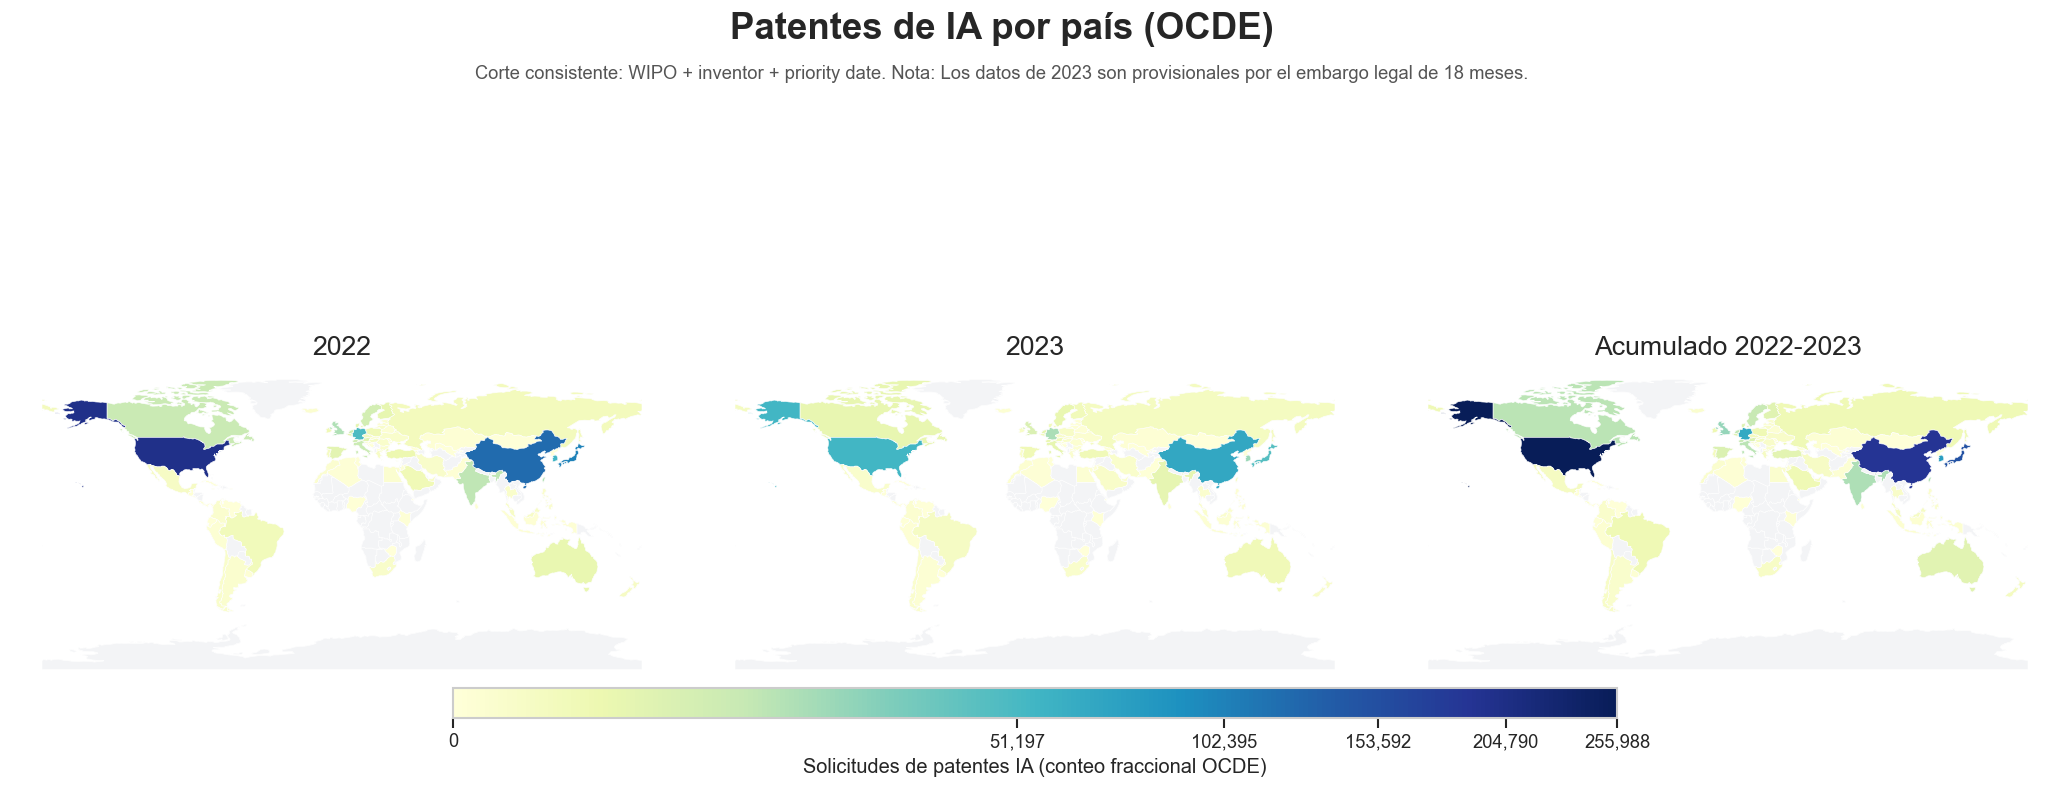

Mapa guardado en: graficos_api_ocde\mapa_patentes_ia_ocde_2022_2023.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.cm import ScalarMappable
from matplotlib.colors import PowerNorm
from matplotlib.ticker import FuncFormatter
import numpy as np # <-- NUEVO: Importamos numpy para los ticks dinámicos
from pathlib import Path
import os

# 1. Configurar directorio y ruta del mapa
DATA_DIR = Path('graficos_api_ocde')
DATA_DIR.mkdir(exist_ok=True)
map_path = DATA_DIR / "mapa_patentes_ia_ocde_2022_2023.png"

# 2. Cargar y preparar los datos de la OCDE
try:
    df_raw = pd.read_csv('OECD.STI.PIE,DSD_PATENTS@DF_PATENTS_OECDSPECIFIC,1.0+.A...PRIORITY...INVENTOR..._T.csv')
    df = df_raw[df_raw['MEASURE'] == 'AP'].copy()

    df = df.rename(columns={
        'REF_AREA': 'iso_a3',
        'TIME_PERIOD': 'year',
        'OBS_VALUE': 'ai_patent_applications'
    })

    df = df[~df['iso_a3'].isin(['W', 'OECD', 'EU27_2020'])]
    df = df[df['year'].isin([2022, 2023])]

    ai_patents = df.groupby(['iso_a3', 'year'], as_index=False)['ai_patent_applications'].sum()
except FileNotFoundError:
    raise FileNotFoundError("Falta el archivo CSV de datos de la OCDE en el directorio actual.")


# 3. Generación del Mapa con Geopandas
try:
    import geopandas as gpd
except ModuleNotFoundError:
    if not map_path.exists():
        raise ModuleNotFoundError("Falta geopandas o el archivo PNG de respaldo.")

    img = mpimg.imread(map_path)
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.imshow(img)
    ax.axis("off")
    plt.show()
else:
    # Cargar mapa mundial
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world.columns = [col.lower() for col in world.columns]
    
    iso_candidates = ["iso_a3", "adm0_a3", "sov_a3", "adm0_a3_us"]
    iso_col = next((col for col in iso_candidates if col in world.columns), None)
    if iso_col is None:
        raise KeyError("No se encontró columna ISO en el shapefile")

    world = world[world[iso_col] != "-99"].copy().rename(columns={iso_col: "iso_a3"})

    year_country = ai_patents.groupby(["year", "iso_a3"], as_index=False)["ai_patent_applications"].sum()
    cum_country = ai_patents.groupby(["iso_a3"], as_index=False)["ai_patent_applications"].sum()

    years_to_plot = [2022, 2023]
    
    vmax = max(
        year_country["ai_patent_applications"].max(),
        cum_country["ai_patent_applications"].max(),
    )
    norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    axes = axes.ravel()

    for ax, year in zip(axes[:2], years_to_plot):
        merged = world.merge(year_country[year_country["year"] == year], on="iso_a3", how="left")
        world.plot(ax=ax, color="#f3f4f6", edgecolor="white", linewidth=0.35)
        merged.plot(column="ai_patent_applications", ax=ax, cmap="YlGnBu", norm=norm, edgecolor="white", linewidth=0.35, missing_kwds={"color": "#f3f4f6"})
        ax.set_title(str(year), fontsize=16)
        ax.axis("off")

    ax = axes[2]
    merged = world.merge(cum_country, on="iso_a3", how="left")
    world.plot(ax=ax, color="#f3f4f6", edgecolor="white", linewidth=0.35)
    merged.plot(column="ai_patent_applications", ax=ax, cmap="YlGnBu", norm=norm, edgecolor="white", linewidth=0.35, missing_kwds={"color": "#f3f4f6"})
    ax.set_title("Acumulado 2022-2023", fontsize=16)
    ax.axis("off")

    # --- INICIO DE LA CORRECCIÓN DE LA LEYENDA ---
    sm = ScalarMappable(norm=norm, cmap="YlGnBu")
    sm.set_array([])
    
    # Hacemos la barra un poco más ancha (aspect=40) para que respiren los números
    cbar = fig.colorbar(sm, ax=axes.tolist(), orientation="horizontal", fraction=0.045, pad=0.06, aspect=40)
    cbar.set_label("Solicitudes de patentes IA (conteo fraccional OCDE)", fontsize=12)
    
    # FIX: Generamos 6 números (ticks) distribuidos equitativamente desde 0 hasta el máximo real
    dynamic_ticks = np.linspace(0, vmax, 6)
    cbar.set_ticks(dynamic_ticks)
    
    # FIX: Formateamos los números con comas para miles y sin decimales (ej: 150,000 en vez de 150000.0)
    cbar.ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{int(x):,}")
    )
    # --- FIN DE LA CORRECCIÓN ---

    fig.suptitle("Patentes de IA por país (OCDE)", fontsize=22, fontweight="bold", y=0.95)
    fig.text(0.5, 0.87, "Corte consistente: WIPO + inventor + priority date. Nota: Los datos de 2023 son provisionales por el embargo legal de 18 meses.", ha="center", fontsize=11, color="#555555")
    fig.subplots_adjust(top=0.75, bottom=0.15, wspace=0.05, hspace=0.12)

    fig.savefig(map_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Mapa guardado en: {map_path}")